In [ ]:
!pip install kagglehub
!pip install pandas
!pip install xgboost
!pip install scikit-learn
!pip install numpy
!pip install matplotlib

# DataSet Loading

In [23]:
import kagglehub
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("asaniczka/forex-exchange-rate-since-2004-updated-daily")

print("Path to dataset files:", path)
filepath = path + "/daily_forex_rates.csv"
df = pd.read_csv(filepath)
df.head()

Path to dataset files: /kaggle/input/forex-exchange-rate-since-2004-updated-daily


,currency,base_currency,currency_name,exchange_rate,date
0,ZWL,EUR,Zimbabwean Dollar,367.466264,2025-06-06
1,GHS,EUR,Ghanaian Cedi,11.697514,2025-06-06
2,HRK,EUR,Croatian Kuna,7.531358,2025-06-06
3,HNL,EUR,Honduran Lempira,29.682829,2025-06-06
4,HKD,EUR,Hong Kong Dollar,8.954919,2025-06-06


In [24]:
df.shape
df.tail(5)

,currency,base_currency,currency_name,exchange_rate,date
421491,JPY,EUR,Japanese Yen,133.3500,2004-09-01
421492,CAD,EUR,Canadian Dollar,1.5967,2004-08-31
421493,JPY,EUR,Japanese Yen,132.8500,2004-08-31
421494,AUD,EUR,Australian Dollar,1.7296,2004-08-31
421495,AUD,EUR,Australian Dollar,1.7237,2004-08-30


In [25]:
kzt_data = df[df['currency'] == 'KZT'].copy()
print(len(kzt_data))

2914


In [26]:
kzt_data.head()

,currency,base_currency,currency_name,exchange_rate,date
84,KZT,EUR,Kazakhstani Tenge,582.236754,2025-06-06
196,KZT,EUR,Kazakhstani Tenge,582.570167,2025-06-05
369,KZT,EUR,Kazakhstani Tenge,584.272246,2025-06-04
582,KZT,EUR,Kazakhstani Tenge,582.457353,2025-06-03
769,KZT,EUR,Kazakhstani Tenge,582.337455,2025-06-02


In [28]:
# 1. Imports
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# 2. Load dataset
print(f"Dataset shape: {df.shape}")

# 3. Filter KZT and sort by date
kzt_data = df[df['currency'] == 'KZT'].copy()
kzt_data['date'] = pd.to_datetime(kzt_data['date'])
kzt_data = kzt_data.sort_values('date').reset_index(drop=True)
print(f"KZT data length: {len(kzt_data)}")

# 4. Compute daily return (percentage change)
kzt_data['return'] = kzt_data['exchange_rate'].pct_change() * 100

# 5. Define target: 1 if return > 0.525%, else 0
THRESHOLD = 0.525
kzt_data['target'] = (kzt_data['return'] > THRESHOLD).astype(int)

# Drop first row due to NaN return
kzt_data.dropna(inplace=True)
kzt_data.reset_index(drop=True, inplace=True)

# 6. Feature engineering
kzt_data['day'] = kzt_data['date'].dt.day
kzt_data['month'] = kzt_data['date'].dt.month
kzt_data['year'] = kzt_data['date'].dt.year
kzt_data['dayofweek'] = kzt_data['date'].dt.dayofweek

# Lag features
lags = [1, 2, 3, 4, 5]
for lag in lags:
    kzt_data[f'exchange_rate_lag_{lag}'] = kzt_data['exchange_rate'].shift(lag)

# Rolling statistics
window_sizes = [3, 7, 14]
for w in window_sizes:
    kzt_data[f'rolling_mean_{w}'] = kzt_data['exchange_rate'].rolling(window=w).mean()
    kzt_data[f'rolling_std_{w}'] = kzt_data['exchange_rate'].rolling(window=w).std()

# Drop NaNs from lag/rolling
kzt_data.dropna(inplace=True)
kzt_data.reset_index(drop=True, inplace=True)

# 7. Prepare features and target
feature_cols = ['day', 'month', 'year', 'dayofweek'] + \
               [f'exchange_rate_lag_{lag}' for lag in lags] + \
               [f'rolling_mean_{w}' for w in window_sizes] + \
               [f'rolling_std_{w}' for w in window_sizes]

X = kzt_data[feature_cols]
y = kzt_data['target']

print(f"Features shape: {X.shape}, Target shape: {y.shape}")
print(f"Class distribution:\n{y.value_counts(normalize=True)}")

# 8. Time-series train-test split (80/20)
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)


# 9. Define model
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight = scale_pos_weight * 1.5
)

# 10. Hyperparameter tuning
tscv = TimeSeriesSplit(n_splits=5)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

print("Starting hyperparameter tuning...")
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)
print(f"Best params: {random_search.best_params_}")
print(f"Best CV accuracy: {random_search.best_score_:.4f}")

# 11. Fit best model
best_model = random_search.best_estimator_
best_model.fit(X_train, y_train)

# 12. Evaluate
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")
print("Classification report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 13. Predict next day
from datetime import timedelta
last_row = kzt_data.iloc[-1]
next_date = last_row['date'] + timedelta(days=1)

next_features = {
    'day': next_date.day,
    'month': next_date.month,
    'year': next_date.year,
    'dayofweek': next_date.dayofweek
}

for lag in lags:
    next_features[f'exchange_rate_lag_{lag}'] = kzt_data['exchange_rate'].iloc[-lag]

for w in window_sizes:
    window_data = kzt_data['exchange_rate'].iloc[-w:]
    next_features[f'rolling_mean_{w}'] = window_data.mean()
    next_features[f'rolling_std_{w}'] = window_data.std()

next_X = pd.DataFrame([next_features])[feature_cols]
next_proba = best_model.predict_proba(next_X)[0, 1]
direction_str = f"STRONG UP ({next_proba:.2%} confidence)" if next_proba > 0.52 else "NO SIGNAL"
print(f"Predicted movement for {next_date.date()}: {direction_str}")

Dataset shape: (421496, 5)
KZT data length: 2914
Features shape: (2900, 15), Target shape: (2900,)
Class distribution:
target
0    0.822414
1    0.177586
Name: proportion, dtype: float64
Starting hyperparameter tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}
Best CV accuracy: 0.4276
Test Accuracy: 0.6707
Classification report:
              precision    recall  f1-score   support

           0       0.98      0.63      0.77       505
           1       0.27      0.92      0.42        75

    accuracy                           0.67       580
   macro avg       0.63      0.78      0.59       580
weighted avg       0.89      0.67      0.72       580

Confusion Matrix:
[[320 185]
 [  6  69]]
Predicted movement for 2025-06-07: NO SIGNAL


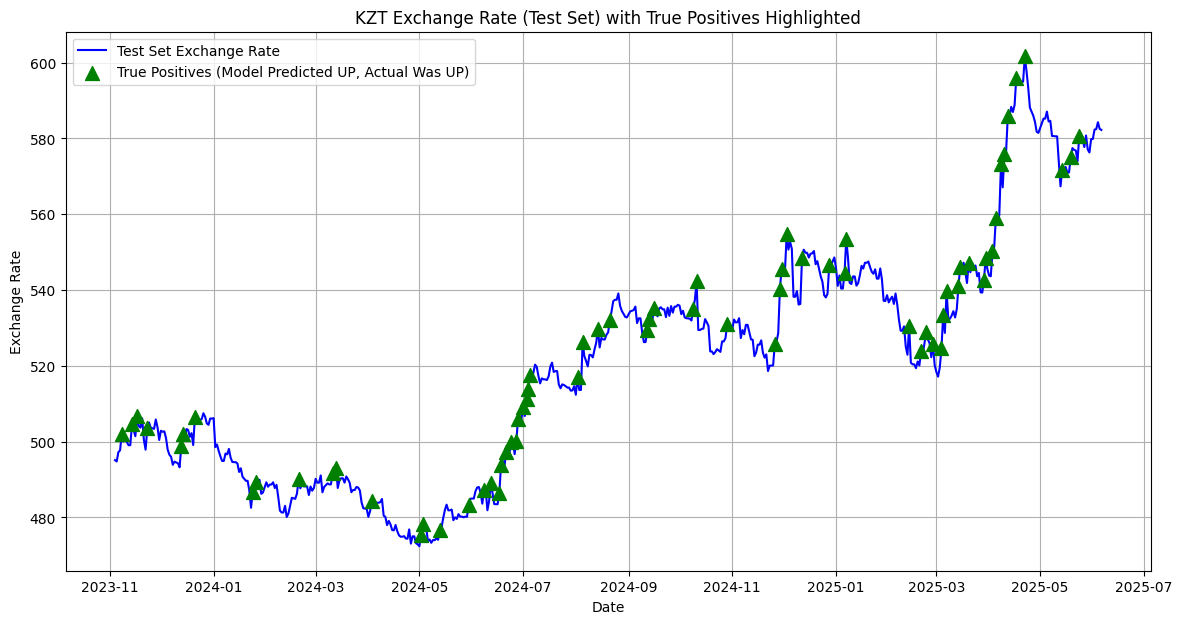

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

true_positives_indices_test = X_test.index[(y_pred == 1) & (y_test == 1)]

# 2. Filter kzt_data to the test set period and get the rows for true positives
# Select rows from kzt_data that correspond to the true positive indices in the test set
true_positive_rows = kzt_data.loc[true_positives_indices_test].copy()

# 3. Filter kzt_data to get only the test set period for the base plot
# This will plot the entire test set's exchange rate
kzt_data_test_period = kzt_data.loc[X_test.index].copy()


# 4. Plotting
plt.figure(figsize=(14, 7))

# Plot the exchange rate for the entire test period
plt.plot(kzt_data_test_period['date'], kzt_data_test_period['exchange_rate'], label='Test Set Exchange Rate', color='blue')

# Highlight the True Positives with a scatter plot
plt.scatter(true_positive_rows['date'], true_positive_rows['exchange_rate'], color='green', label='True Positives (Model Predicted UP, Actual Was UP)', marker='^', s=100, zorder=5) # zorder to ensure markers are on top

# Add titles and labels
plt.title('KZT Exchange Rate (Test Set) with True Positives Highlighted')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Model